In [1]:
import os
import sys

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import sim_data_analysis as sda

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=18, count=4, shape="square"
)

fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    reducing_agent="mea",
    concentration=100,
    ph=7.5,
)

transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7, 14:1e3, 13:4e4})
#transition_set = transition_set.filter_by_identity([19])
transition_set.finalize()

In [3]:
transition_set.transition_df

transition_type  \
Fluorophore                          identity                                           
cy5_dna                              0                      TransitionType.EXCITATION   
                                     1            TransitionType.FLUORESCENT_EMISSION   
                                     2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                     3         TransitionType.INTERSYSTEM_CROSSING_TS   
                                     4                   TransitionType.ISOMERIZATION   
                                     5                      TransitionType.PHOTO_BISO   
                                     6                      TransitionType.THERM_BISO   
                                     7           TransitionType.INTERNAL_CONVERSION_S   
                                     8                      TransitionType.ET_CYCLE_T   
                                     9                      TransitionType.ET_CYCLE_S   
                                     10                    TransitionType.REDUCTION_T   
                                     11                    TransitionType.REDUCTION_S   
                                     12                    TransitionType.OXIDATION_1   
                                     13                     TransitionType.RAD_ESCAPE   
                                     14                      TransitionType.RAD_RELAX   
                                     15               TransitionType.PHOTOBLEACHING_1   
D: cy5_dna, A: cy5_dna, dist: 18.0   16                     TransitionType.CIS_FRET_1   
                                     17                     TransitionType.CIS_FRET_2   
                                     18                     TransitionType.OFF_FRET_1   
                                     19                           TransitionType.FRET   
                                     20               TransitionType.S_T_ANNIHILATION   
D: cy5_dna, A: cy5_dna, dist: 25.456 21                     TransitionType.CIS_FRET_1   
                                     22                     TransitionType.CIS_FRET_2   
                                     23                     TransitionType.OFF_FRET_1   
                                     24                           TransitionType.FRET   
                                     25               TransitionType.S_T_ANNIHILATION   

                                              abbreviation  \
Fluorophore                          identity                
cy5_dna                              0                 EXC   
                                     1                 FLU   
                                     2               ISCST   
                                     3               ISCTS   
                                     4                 ISO   
                                     5               PBISO   
                                     6               TBISO   
                                     7                 ICS   
                                     8                 ETT   
                                     9                 ETS   
                                     10               REDT   
                                     11               REDS   
                                     12               OXI1   
                                     13                 RE   
                                     14                 RR   
                                     15               BLE1   
D: cy5_dna, A: cy5_dna, dist: 18.0   16             CFRET1   
                                     17             CFRET2   
                                     18             OFRET1   
                                     19               FRET   
                                     20                STA   
D: cy5_dna, A: cy5_dna, dist: 25.456 21             CFRET1   
                                     22             CFRET2   
                           

In [7]:
number_of_simulations = 1
memory = 30
threshold = 10

WARNING for line:                     transform=axes2[0, 0].transAxes, bbox=dict(facecolor='white', edgecolor='black'))
 Creating legend with loc="best" can be slow with large amounts of data. 
WARNING for line:         ax.set_yscale(yscale)
 Data has no positive values, and therefore cannot be log-scaled. 
WARNING for line:                 func(*args, **kwargs)
 Creating legend with loc="best" can be slow with large amounts of data. 
WARNING for line:     fig.canvas.print_figure(bytes_io, **kw)
 Creating legend with loc="best" can be slow with large amounts of data. 


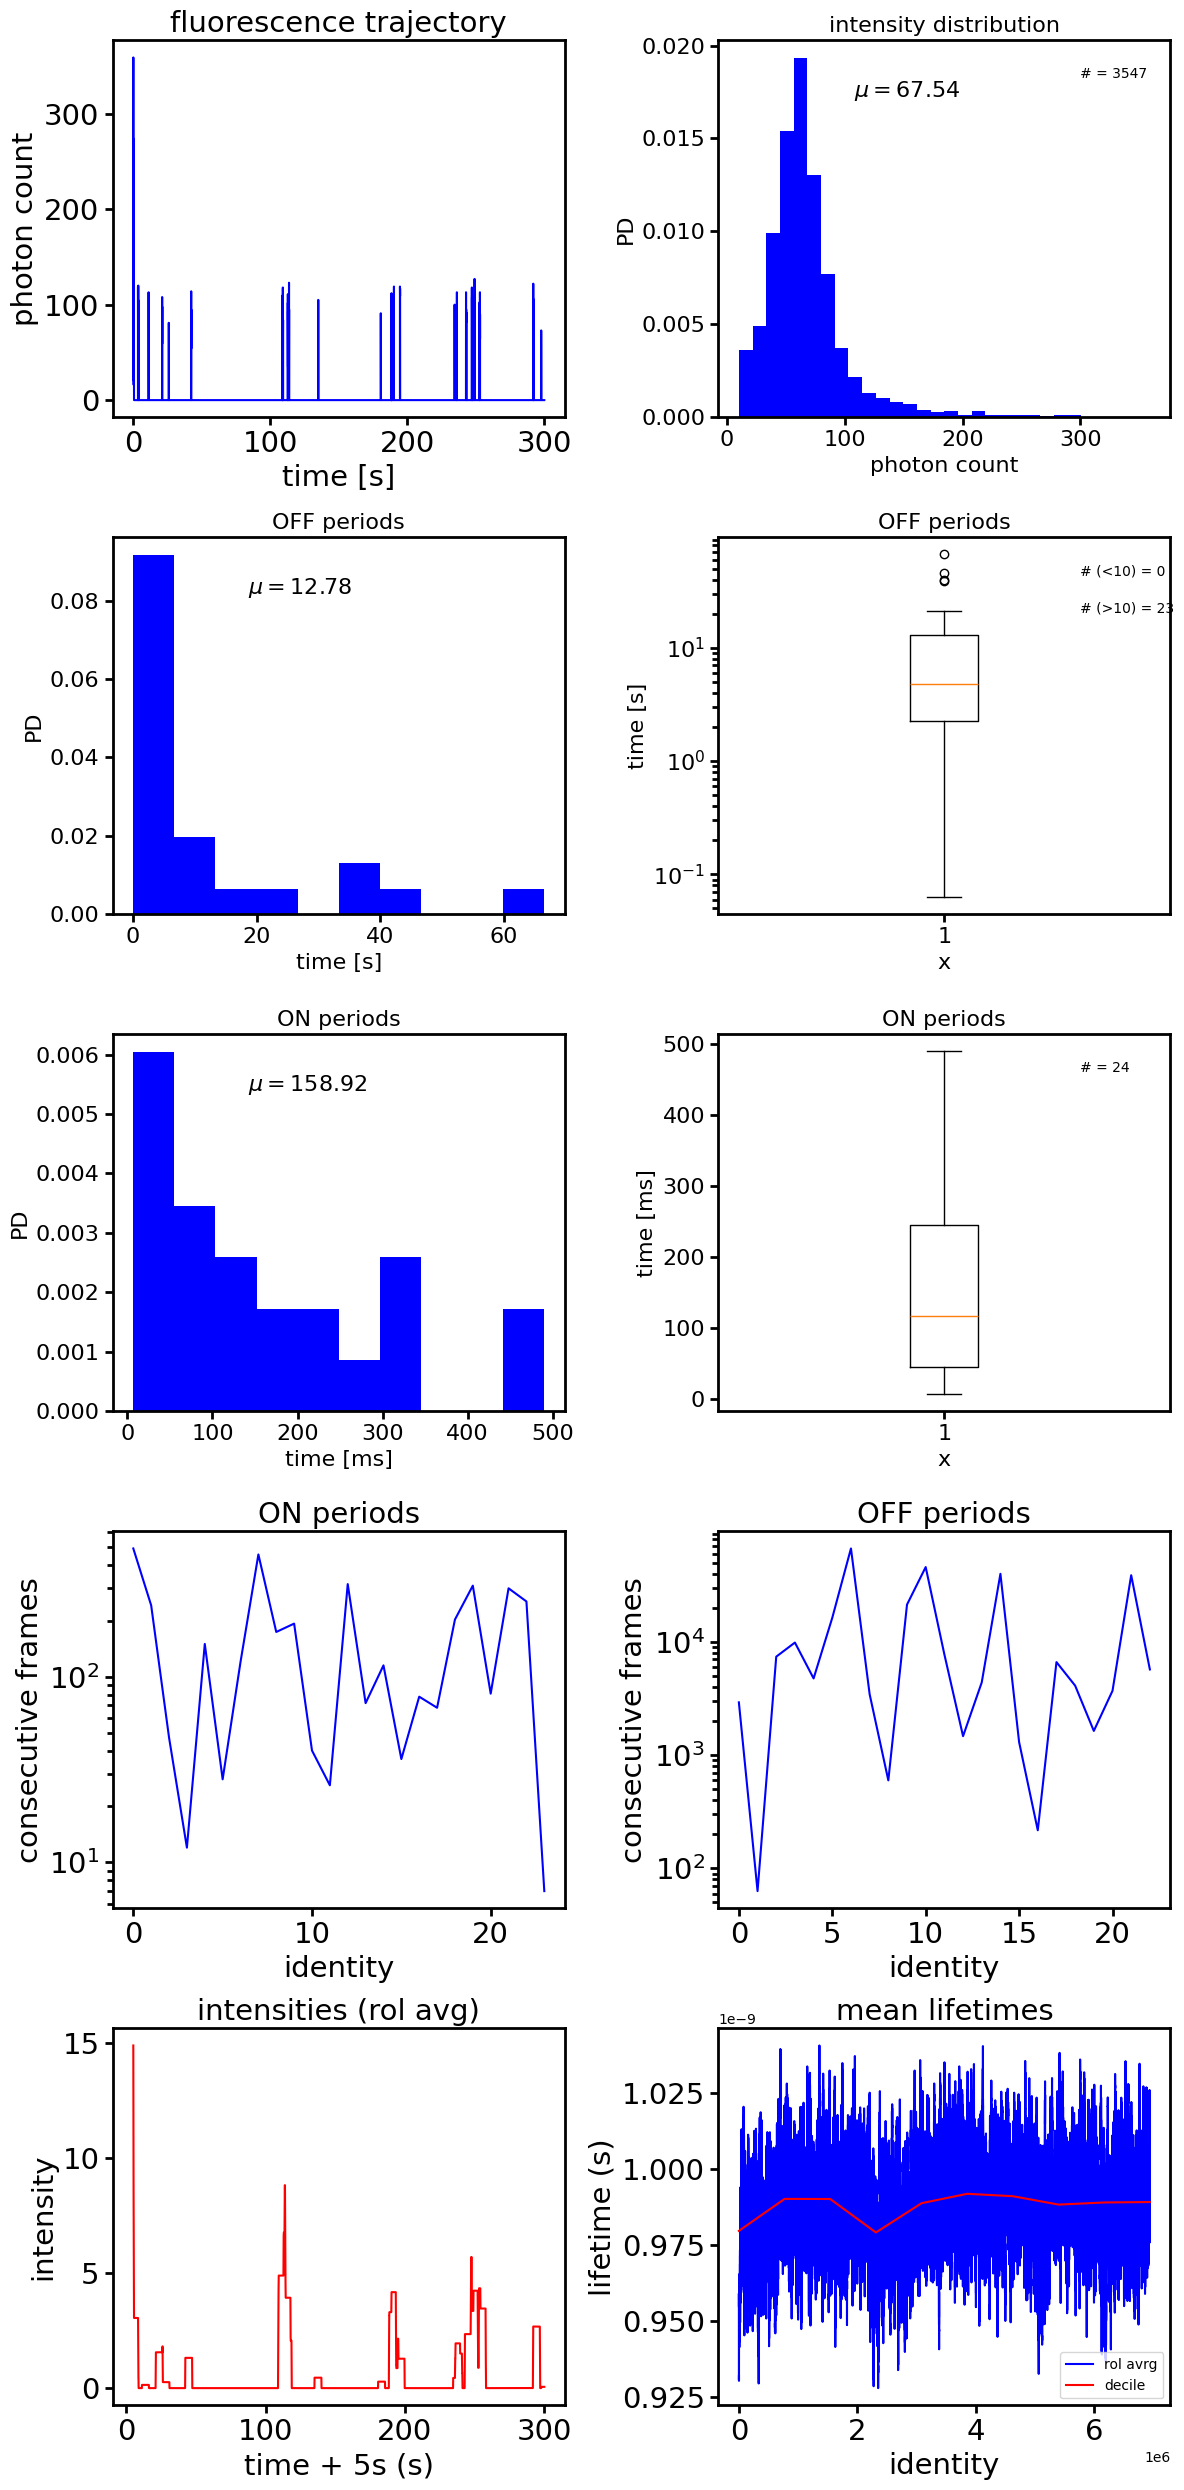

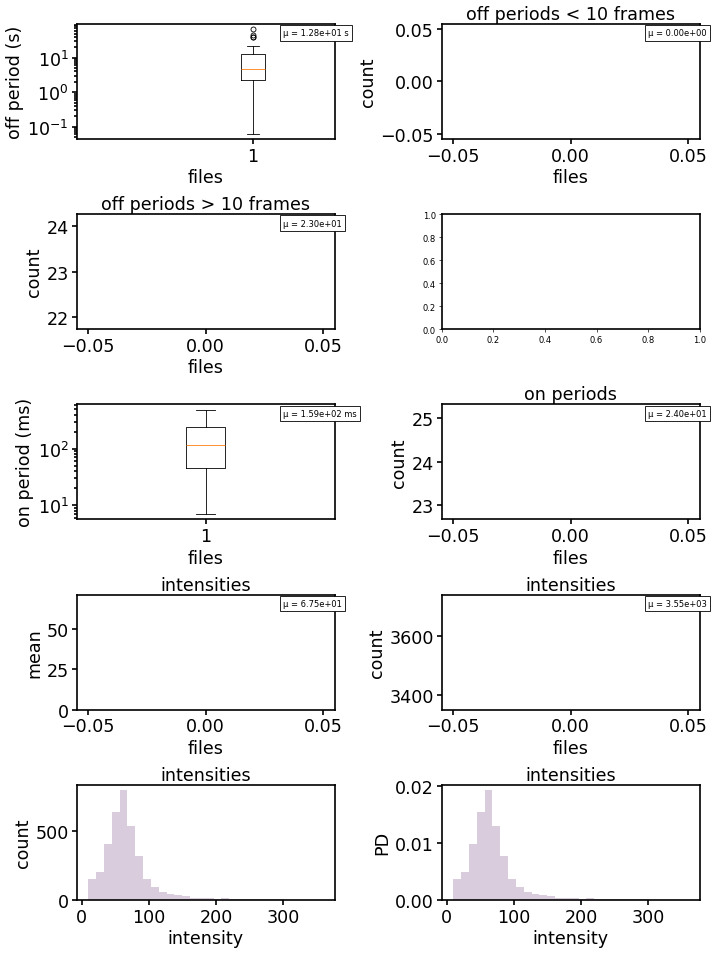

In [13]:
sda.simulate_data(number_of_simulations=number_of_simulations, memory=memory, threshold=threshold, transition_set=transition_set)

In [4]:
rng = np.random.default_rng(10)
simulation = si.Simulation(transition_set=transition_set)
simulation.run(size=1e7, end_time=None, seed=rng)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=100)

KeyboardInterrupt: 

In [40]:
emis.extract(simulation)
photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
emis.add_photon_collection_objective(p=photon_collection_rate, seed=100) 
emis.add_quantum_efficiency(p=0.9, seed=100)
emis.add_poisson_noise(rate=0.6, seed=100)
emis.apply_threshold(threshold=10)

array([[<Axes: title={'center': 'fluorescence trajectory'}, xlabel='time [s]', ylabel='photon count'>]],
      dtype=object)

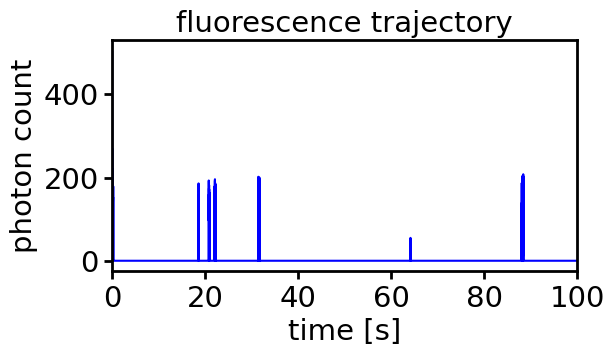

In [45]:
emis.plot_time_series(xlim=[0, 100])

In [43]:
blinks = bl.Blinking(emis, memory=10)

In [44]:
blinks.off_periods

array([18320,  2179,  1136,  9174, 32459, 23892, 19985,  3892,  8467,
        3851, 16064, 37664, 30154, 79625,  6968,  4363, 12564,  5997,
        6326, 21700,  5840,  6374,  2548, 14461,   847,  6104,  1559,
       11306,   796,    11, 28357,  1957, 59209,  5683,  5834,  4069,
       57342, 28115,  5199])

array([[<AxesSubplot:title={'center':'ON periods'}, xlabel='x', ylabel='time [ms]'>]],
      dtype=object)

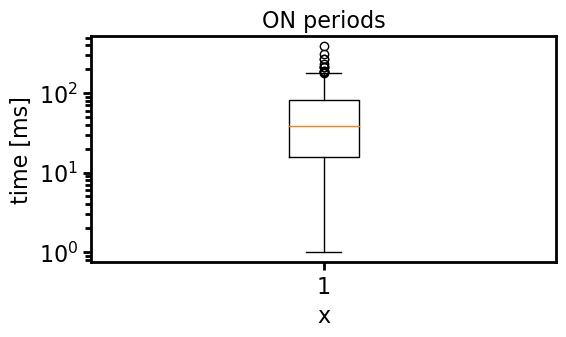

In [21]:
blinks.plot('on_boxplot', as_time='ms', yscale='log')

array([[<Axes: title={'center': 'OFF periods'}, xlabel='x', ylabel='time [s]'>]],
      dtype=object)

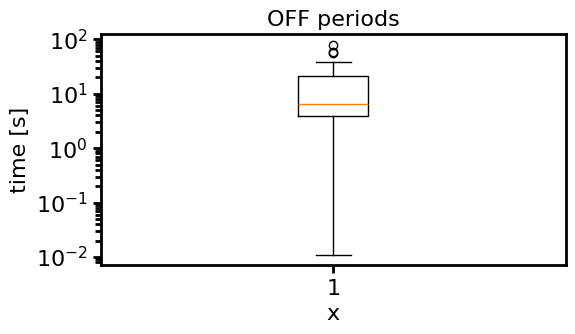

In [47]:
blinks.plot('off_boxplot', as_time='s', yscale='log')

array([[<AxesSubplot:title={'center':'intensity distribution'}, xlabel='photon count', ylabel='PD'>]],
      dtype=object)

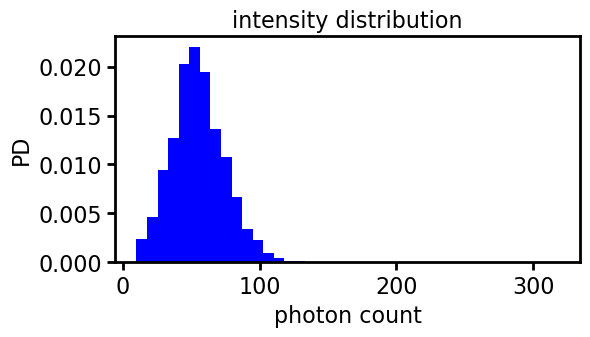

In [29]:
emis.plot_histogram(bins=40)

In [3]:
fluorophores = fl.construct_fluorophores(
    name="cy5_gidi", distance=3, count=2, shape="square"
)

fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    irradiance=2.5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    reducing_agent="mea",
    concentration=100,
    ph=8,
)

In [4]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

In [5]:
transition_set.transition_df

transition_type  \
Fluorophore                         identity                                           
cy5_gidi                            0                      TransitionType.EXCITATION   
                                    1            TransitionType.FLUORESCENT_EMISSION   
                                    2         TransitionType.INTERSYSTEM_CROSSING_ST   
                                    3         TransitionType.INTERSYSTEM_CROSSING_TS   
                                    4                   TransitionType.ISOMERIZATION   
                                    5               TransitionType.BACKISOMERIZATION   
                                    6           TransitionType.INTERNAL_CONVERSION_S   
                                    7                      TransitionType.ET_CYCLE_T   
                                    8                      TransitionType.ET_CYCLE_S   
                                    9                     TransitionType.REDUCTION_T   
                                    10                    TransitionType.REDUCTION_S   
                                    11                    TransitionType.OXIDATION_1   
                                    12               TransitionType.PHOTOBLEACHING_1   
D: cy5_gidi, A: cy5_gidi, dist: 3.0 13                     TransitionType.CIS_FRET_2   
                                    14                     TransitionType.OFF_FRET_1   
                                    15                           TransitionType.FRET   
                                    16               TransitionType.S_T_ANNIHILATION   

                                             abbreviation  \
Fluorophore                         identity                
cy5_gidi                            0                 EXC   
                                    1                 FLU   
                                    2               ISCST   
                                    3               ISCTS   
                                    4                 ISO   
                                    5                BISO   
                                    6                 ICS   
                                    7                 ETT   
                                    8                 ETS   
                                    9                REDT   
                                    10               REDS   
                                    11               OXI1   
                                    12               BLE1   
D: cy5_gidi, A: cy5_gidi, dist: 3.0 13             CFRET2   
                                    14             OFRET1   
                                    15               FRET   
                                    16                STA   

                                                    initial_state  \
Fluorophore                         identity                        
cy5_gidi                            0              SingleState.S0   
                                    1              SingleState.S1   
                                    2              SingleState.S1   
                                    3              SingleState.T1   
                                    4              SingleState.S1   
                                    5             SingleState.Cis   
                                    6              SingleState.S1   
                                    7              SingleState.T1   
                                    8              SingleState.S1   
                                    9              SingleState.T1   
                                    10             SingleState.S1   
                                    11           SingleState.OFF1   
                                    12             SingleState.T1   
D: cy5_gidi, A: cy5_gidi, dist: 3.0 13         PairedState.S1_Cis   
                                    14        PairedState.S1_OFF1   
                                    15          PairedState.S1_